=== Week 4 Day 1 — Math & Correlation Analysis ===
(120, 12)
Index(['EmpID', 'Name', 'Department', 'JobTitle', 'Age', 'Gender',
       'ExperienceYears', 'Salary', 'BonusPercent', 'PerformanceScore',
       'RemoteWork', 'ManagerID'],
      dtype='object')
The mean salary among the employees is $7849.36.
The median salary among the employees is $8374.6.
The mode salary among the employees is $3523.04.
Salary has greater spread compared to Experience.
                       Salary  ExperienceYears
Salary           6.464766e+06       704.457073
ExperienceYears  7.044571e+02        30.487115
                     EmpID       Age  ExperienceYears    Salary  BonusPercent  \
EmpID             1.000000 -0.061259         0.100062 -0.029911      0.025359   
Age              -0.061259  1.000000        -0.049705 -0.138787      0.021172   
ExperienceYears   0.100062 -0.049705         1.000000  0.050179      0.086400   
Salary           -0.029911 -0.138787         0.050179  1.000000     -0.023386   

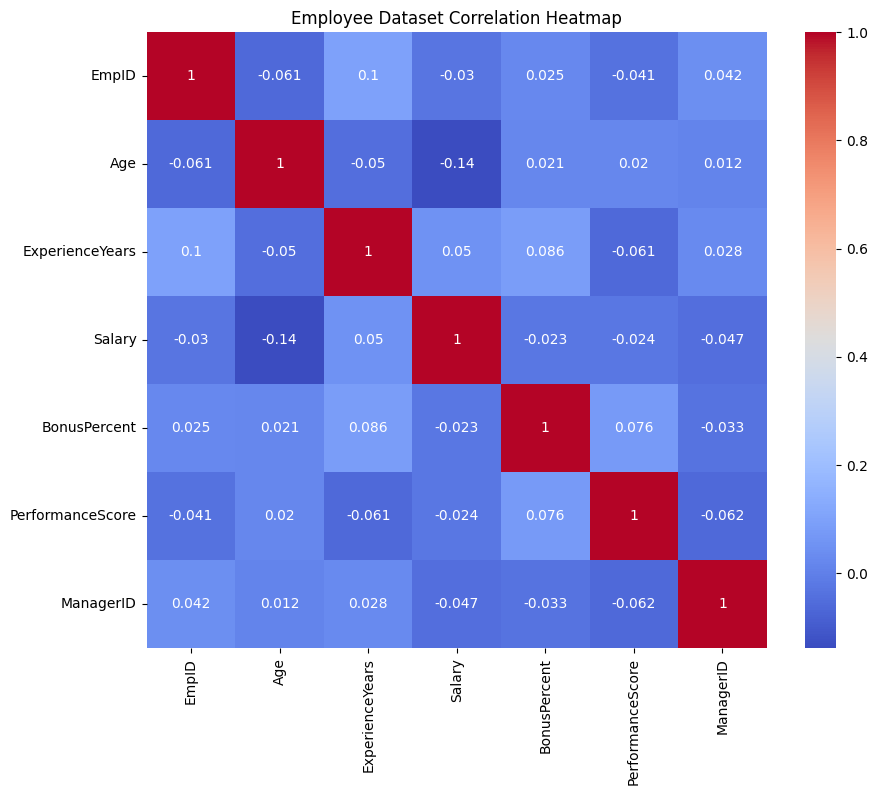

In [ ]:
# -------------------------------------------------------------
# Part A — Setup & Load
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Week 4 Day 1 — Math & Correlation Analysis ===")

# TODO 1: Load Employees.csv
employees = pd.read_csv('Employees.csv')
# TODO 2: Display shape, columns, and first few rows
print(employees.shape)
print(employees.columns)
employees.head(5)
# -------------------------------------------------------------
# Part B — Central Tendencies
# -------------------------------------------------------------
# TODO 3: Compute mean, median, and mode for Salary
# TODO 4: Round or format neatly
mean_salary = employees['Salary'].mean().round(2)
median_salary = employees['Salary'].median()
mode_salary = employees['Salary'].mode()[0]
print(f"The mean salary among the employees is ${mean_salary}.")
print(f"The median salary among the employees is ${median_salary}.")
print(f"The mode salary among the employees is ${mode_salary}.")
# -------------------------------------------------------------
# Part C — Spread (Variance & StdDev)
# -------------------------------------------------------------
# TODO 5: Compute variance and std-dev for Salary and ExperienceYears
variance_salary = employees['Salary'].var()
std_salary = employees['Salary'].std()

variance_exp = employees['ExperienceYears'].var()
std_exp = employees['ExperienceYears'].std()
# TODO 6: Compare which column has greater spread
if std_salary > std_exp:
  print("Salary has greater spread compared to Experience.")
else:
  print("Experience has greater spread to Salary.")
# -------------------------------------------------------------
# Part D — Covariance & Correlation
# -------------------------------------------------------------
# TODO 7: Compute covariance matrix for Salary & ExperienceYears
covariance = employees[['Salary','ExperienceYears']].cov()
print(covariance)
# TODO 8: Compute correlation matrix for all numeric columns
correlation = employees.corr(numeric_only=True)
print(correlation)
# TODO 9: Interpret which variable correlates most with Salary
salary_corr = correlation['Salary'].sort_values(ascending = False)
most_corr = salary_corr.index[1]
most_val = salary_corr.iloc[1].round(2)
print(f"{most_corr} correlates most with salary with a correlation coefficient of {most_val}.")
# -------------------------------------------------------------
# Part E — Visualization (Optional)
# -------------------------------------------------------------
# TODO 10: Use seaborn heatmap to plot correlation matrix
# TODO 11: Add title “Employee Dataset Correlation Heatmap”
plt.figure(figsize= (10,8))
sns.heatmap(data = correlation,annot=True,cmap= "coolwarm")
plt.title("Employee Dataset Correlation Heatmap")
plt.show()




The initial cost is  61214188.70835247
Learned base:  2938.7714567109165
Learned slope:  826.095214946999
Final Slope is  826.095214946999
Final Base is  2938.7714567109165


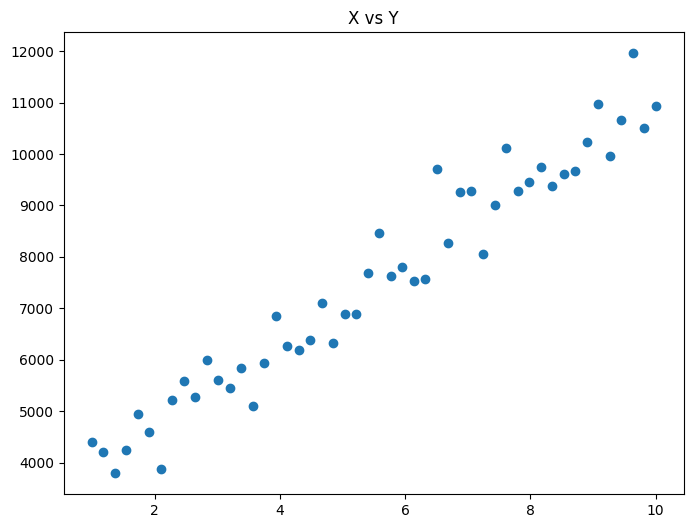

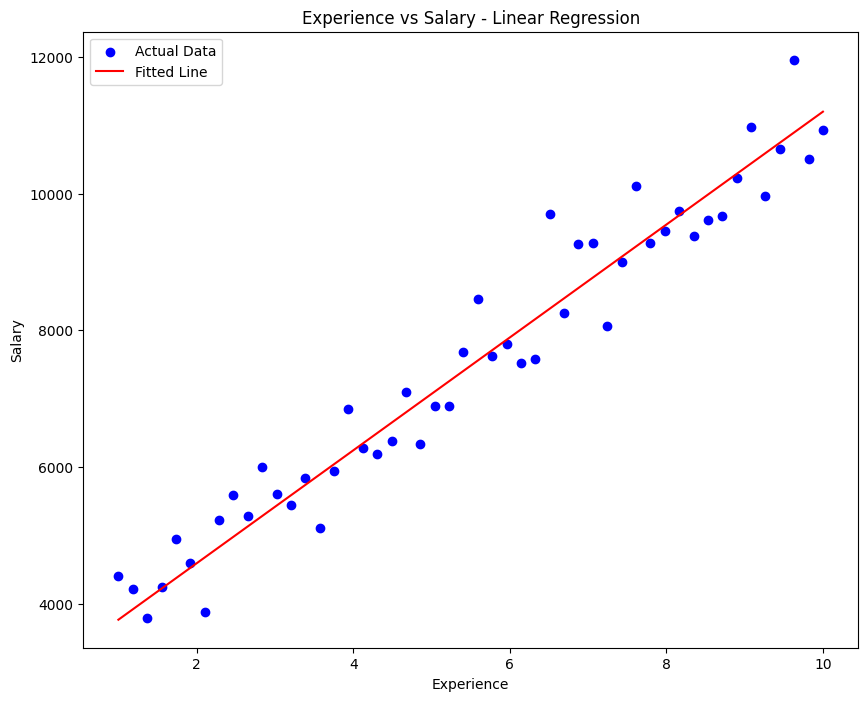

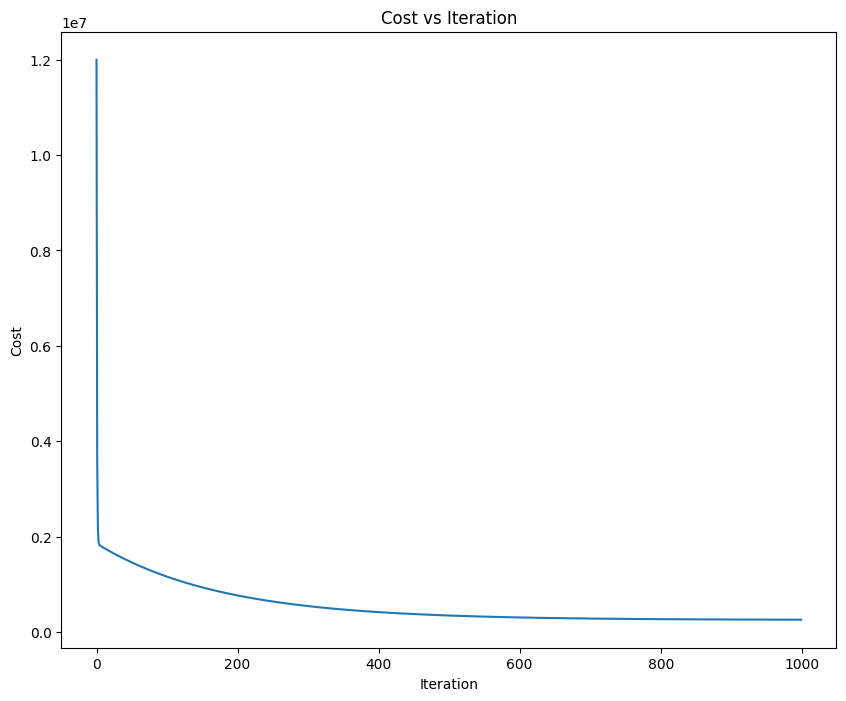

From Gradient Descent 
 Slope =  826.095214946999 
 Base =  2938.7714567109165
From Polyfit 
 Slope =  800.8583366693737 
 Base =  3108.964698246193


In [ ]:
# -------------------------------------------------------------
# Part A — Setup & Generate Simple Data
# -------------------------------------------------------------
# TODO 1: import numpy and matplotlib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# TODO 2: Create X = Experience (1–10, 50 points) using np.linspace()
experience = np.linspace(1,10,50)
# TODO 3: Create true relationship → Salary = base + slope × X + noise
#          Hint: base ≈ 3000, slope ≈ 800, noise ≈ np.random.randn()*500
base = 3000
slope = 800
salary = base + slope*experience + np.random.randn(len(experience))*500
# TODO 4: Plot scatter (X vs Y) to see rough trend
plt.figure(figsize=(8,6))
plt.title('X vs Y')
plt.scatter(x= experience,y= salary)
# -------------------------------------------------------------
# Part B — Define the Cost Function
# -------------------------------------------------------------
# TODO 5: Define a function cost_function(m, b, X, Y)
#          that computes Mean Squared Error (MSE):
#          J = (1/n) * Σ (y – (m x + b))²
def cost_function(slope,base,experience,salary):
  return ((salary - (slope*experience+base))**2).mean()
# TODO 6: Test it with m = 0, b = 0 and print the cost
initial_cost = cost_function(0,0,experience,salary)
print("The initial cost is ",initial_cost)
# -------------------------------------------------------------
# Part C — Implement Gradient Descent Loop
# -------------------------------------------------------------
# TODO 7: Initialize m and b to 0
slope = 0
cost =[]
base = 0
n = len(experience)
# TODO 8: Set learning_rate (α) ≈ 0.0001 and iterations ≈ 1000
learning_rate = 0.0077
iterations = 1000
# TODO 9: Loop over iterations:
#           • Predict y_pred = m × X + b
#           • Compute gradients dm, db:
#             dm = –(2/n) Σ x (y – y_pred)
#             db = –(2/n) Σ (y – y_pred)
#           • Update m, b:
#             m = m – α × dm
#             b = b – α × db
for i in range(iterations):
  salary_pred = slope*experience + base
  slope_grad = (-(2/n) * sum(experience* (salary - salary_pred)))
  base_grad = (-(2/n) * sum(salary - salary_pred))
  slope = slope - (learning_rate*slope_grad)
  base = base - (learning_rate*base_grad)
# TODO 10: Optionally store cost each iteration to plot convergence later
  cost.append(cost_function(slope,base,experience,salary))
print("Learned base: ", base)
print("Learned slope: ", slope)
# -------------------------------------------------------------
# Part D — Visualize Results
# -------------------------------------------------------------
# TODO 11: Print final m and b
print('Final Slope is ', slope)
print('Final Base is ', base)
# TODO 12: Plot scatter (X,Y) and the learned line (y_pred) on top
final_pred = slope * experience + base
plt.figure(figsize= (10,8))
plt.title('X vs Y - Scatter')
plt.scatter(experience,salary,color = 'blue', label = 'Actual Data')
plt.plot(experience,final_pred,color = 'red', label = 'Fitted Line' )
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary - Linear Regression')
plt.legend()
plt.show()
# TODO 13: Plot cost vs iteration (if you stored it) to see descent
plt.figure(figsize= (10,8))
plt.title('Cost vs Iteration')
plt.plot(range(iterations),cost)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.show()
# -------------------------------------------------------------
# Part E — Compare to Analytical Solution
# -------------------------------------------------------------
# TODO 14: Use NumPy’s polyfit(X,Y,1) to get best-fit m,b directly
polyfit =np.polyfit(experience,salary,1)
# TODO 15: Print both (m,b) from Gradient Descent vs polyfit()
print("From Gradient Descent \n Slope = ",slope,"\n Base = ",base)
print("From Polyfit \n Slope = ",polyfit[0],"\n Base = ",polyfit[1])
# TODO 16: Comment how close they are

=== Linear Regression with scikit-learn ===
Slope = [2676.98519651]
Intercept = 32382.592989316283
MAE = 3402.1557785022164
MSE = 17774992.220716253
RMSE = 4216.0398741848085
R² = 0.9789111151338923


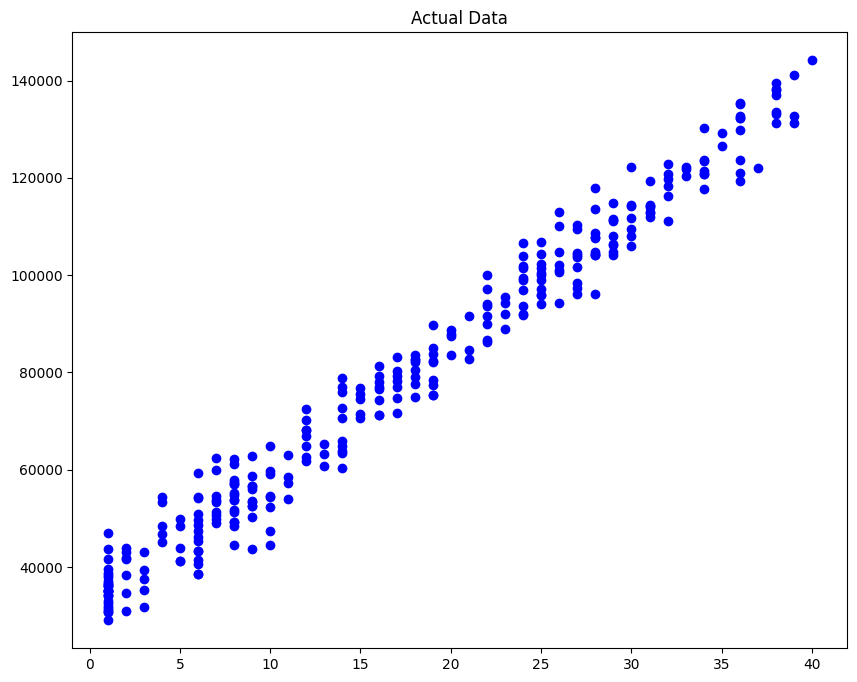

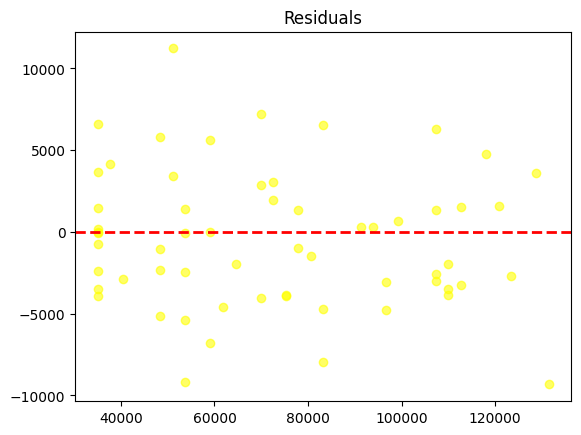

Learned Slope:  [2676.98519651] 
 Learned Base:  32382.592989316283
Using Polyfit 
 Slope:  2671.2859079856253 
 Base:  32380.683281356844


In [ ]:
from math import sqrt
# -------------------------------------------------------------
#  Linear Regression with scikit-learn
# -------------------------------------------------------------

# Part A — Setup & Load Data
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=== Linear Regression with scikit-learn ===")

# TODO 1: Load Employees.csv
employees= pd.read_csv('Employees_Linear_Full.csv')

# TODO 2: Choose features (X) and target (y)
# Example: Salary vs ExperienceYears
X = employees[['ExperienceYears']]
y = employees['Salary']

# -------------------------------------------------------------
# Part B — Train/Test Split
# -------------------------------------------------------------
# TODO 3: Split into train and test (test_size = 0.2)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
# -------------------------------------------------------------
# Part C — Train Linear Regression Model
# -------------------------------------------------------------
# TODO 4: Create LinearRegression() and fit it on X_train, y_train
model = LinearRegression()
model.fit(X_train, y_train)
# TODO 5: Print learned slope (coef_) and intercept (intercept_)
slope = model.coef_
base = model.intercept_
print("Slope =", model.coef_)
print("Intercept =", model.intercept_)
# -------------------------------------------------------------
# Part D — Predictions & Evaluation
# -------------------------------------------------------------
# TODO 6: Predict on X_test
y_pred = model.predict(X_test)
# TODO 7: Compute MAE, MSE, RMSE, R²
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R² =", r2)
# -------------------------------------------------------------
# Part E — Visualizations
# -------------------------------------------------------------
# TODO 8: Plot actual vs predicted
plt.figure(figsize=(10,8))
plt.title('Actual Data')
plt.scatter(X,y,color='blue')
plt.show()
# TODO 9: Plot residuals
residuals = y_test - y_pred
plt.scatter(y_pred,residuals,color='yellow',alpha=0.6)
plt.title('Residuals')
plt.axhline(0,color='red',linestyle='--',linewidth=2)
plt.show()

# -------------------------------------------------------------
# Part F — Compare with Numpy Polyfit
# -------------------------------------------------------------
# TODO 10: Compute slope & intercept using np.polyfit
m_pf, b_pf = np.polyfit(employees['ExperienceYears'],y,1)
# TODO 11: Print comparison
print('Learned Slope: ', slope,'\n Learned Base: ',base)
print('Using Polyfit \n Slope: ',m_pf,'\n Base: ',b_pf)


=== Multivariable Regression ===
Slope:  [  268.75548789 30303.0246144   -124.1975262   -121.12476067]
Base:  80490.24779166667
MAE =  8261.829979658189
MSE =  86361691.73439029
RMSE =  9293.099145838825
R² =  0.8975374081060807


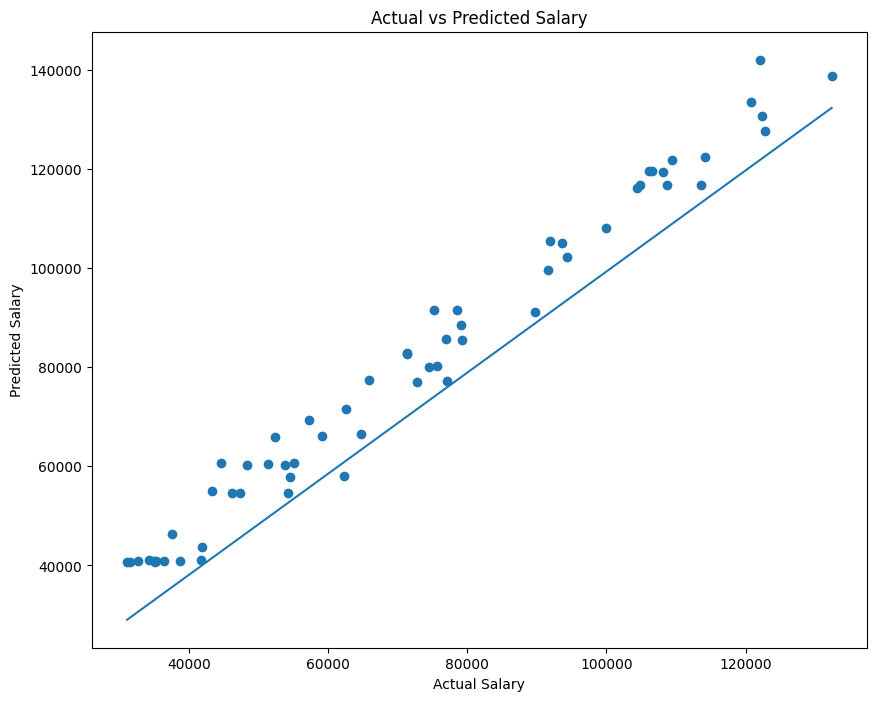

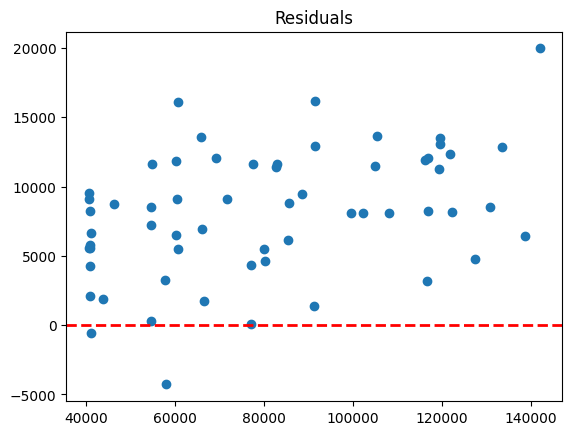

Age: 268.7554878943032
ExperienceYears: 30303.02461440324
PerformanceScore: -124.19752620382906
BonusPercent: -121.12476067149169


In [27]:
# -------------------------------------------------------------
# Week 4 Day 4 — Multivariable Linear Regression
# -------------------------------------------------------------

# Part A — Setup
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=== Multivariable Regression ===")

# TODO 1: Load Employees.csv
employees = pd.read_csv('Employees_Linear_Full.csv')
# -------------------------------------------------------------
# Part B — Feature Engineering
# -------------------------------------------------------------
# TODO 2: One-hot encode categorical columns (Department)
employees = pd.get_dummies(employees,columns=['Department'],drop_first = True)
# TODO 3: Select at least 3–5 features
X = employees[['Age','ExperienceYears','PerformanceScore','BonusPercent']]
y = employees['Salary']
# -------------------------------------------------------------
# Part C — Model Training
# -------------------------------------------------------------
# TODO 4: Train/test split (test_size=0.2)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)
# -------------------------------------------------------------
# Part D — Scaling (optional but recommended)
# -------------------------------------------------------------
# TODO 5: Initialize scaler and fit_transform on X_train, transform X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# TODO 6: Fit LinearRegression model on scaled features
model = LinearRegression()
model.fit(X_train_scaled,y_train)

# TODO 7: Print model coefficients + intercept
slope = model.coef_
base = model.intercept_
print('Slope: ', slope)
print('Base: ', base)
# -------------------------------------------------------------
# Part E — Predictions & Evaluation
# -------------------------------------------------------------
# TODO 8: Predict on X_test_scaled
y_pred = model.predict(X_test_scaled)
# TODO 9: Calculate MAE, MSE, RMSE, R²
print('MAE = ', mean_absolute_error(y_test,y_pred))
print('MSE = ', mean_squared_error(y_test,y_pred))
print('RMSE = ', np.sqrt(mean_squared_error(y_test,y_pred)))
print('R² = ', r2_score(y_test,y_pred))
# -------------------------------------------------------------
# Part F — Visualization
# -------------------------------------------------------------
# TODO 10: Plot Actual vs Predicted Salary
plt.figure(figsize = (10,8))
plt.title('Actual vs Predicted Salary')
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_train.min(),y_test.max()],linewidth = 1.5)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.show()
# TODO 11: Plot residuals
residuals = y_pred - y_test
plt.scatter(y_pred,residuals)
plt.title('Residuals')
plt.axhline(0,color='red',linestyle='--',linewidth=2)
plt.show()
# -------------------------------------------------------------
# Part G — Interpretation
# -------------------------------------------------------------
# TODO 12: Print feature names next to coefficients (very important!)
for name,coef in zip(X.columns,model.coef_):
  print(f"{name}: {coef}")

